# EC9630 Machine Learning - Laboratory 1

Task: STASTICAL PATTEN CLASSIFICATION – DECISION TREE AND INFORMATION GAIN

Name: Jayasinghe K.J.M.U.G.S.E.

Reg No: 2021/E/075

Date: 31/01/2025

Time: 1.30

1. Setup and Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_binary_health_indicators_BRFSS2015.csv to diabetes_binary_health_indicators_BRFSS2015.csv


2. Loading the Dataset

In [10]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

3. data analysis

In [11]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [12]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [13]:
print("Dataset Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print("\nData Summary:\n")
print(df.info())

Dataset Shape: (253680, 22)
Column Names: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data Summary:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          2536

In [14]:
print(df.dtypes)

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


In [15]:
print(df.describe())

       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001       0.424121       0.962670   
std           0.346294       0.494934       0.494210       0.189571   
min           0.000000       0.000000       0.000000       0.000000   
25%           0.000000       0.000000       0.000000       1.000000   
50%           0.000000       0.000000       0.000000       1.000000   
75%           0.000000       1.000000       1.000000       1.000000   
max           1.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0.094186   
std         6.608694       0.496761       0.197294              0.292087   
min        12.000000       0.000000       0.000000      

4. Data Visualization

In [16]:
# Checking for missing values
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


<Axes: xlabel='Age', ylabel='Diabetes_binary'>

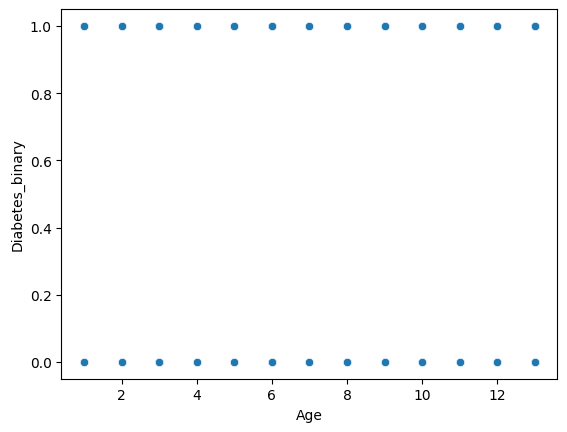

In [17]:
sns.scatterplot(x=df['Age'], y=df['Diabetes_binary'])

In [18]:
df1 = df.set_index("Age")
df1.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Education,Income
Age,,,,,,,,,,,,,,,,,,,,,
9.0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,4.0,3.0
7.0,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,6.0,1.0
9.0,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,4.0,8.0
11.0,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,6.0
11.0,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,5.0,4.0


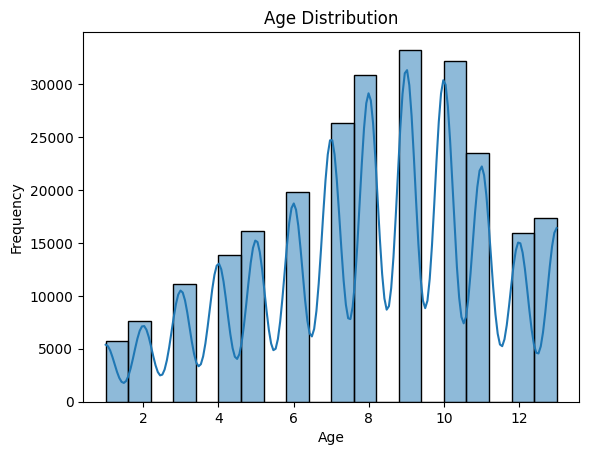

In [19]:
sns.histplot(df1.index, bins=20, kde=True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [20]:
print(df['Diabetes_binary'].value_counts())

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


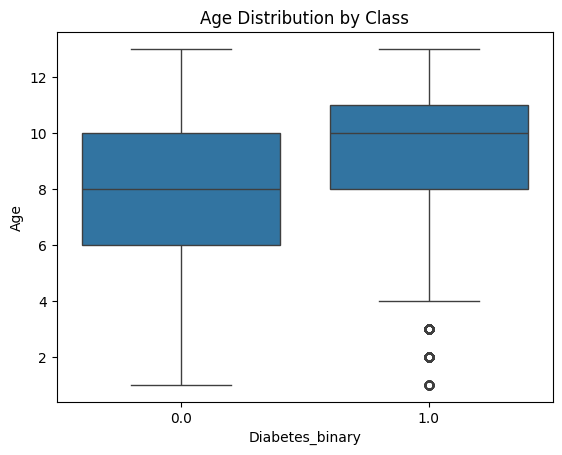

In [21]:
# Box plot for Age vs. Class
sns.boxplot(x='Diabetes_binary', y='Age', data=df)
plt.title('Age Distribution by Class')
plt.show()

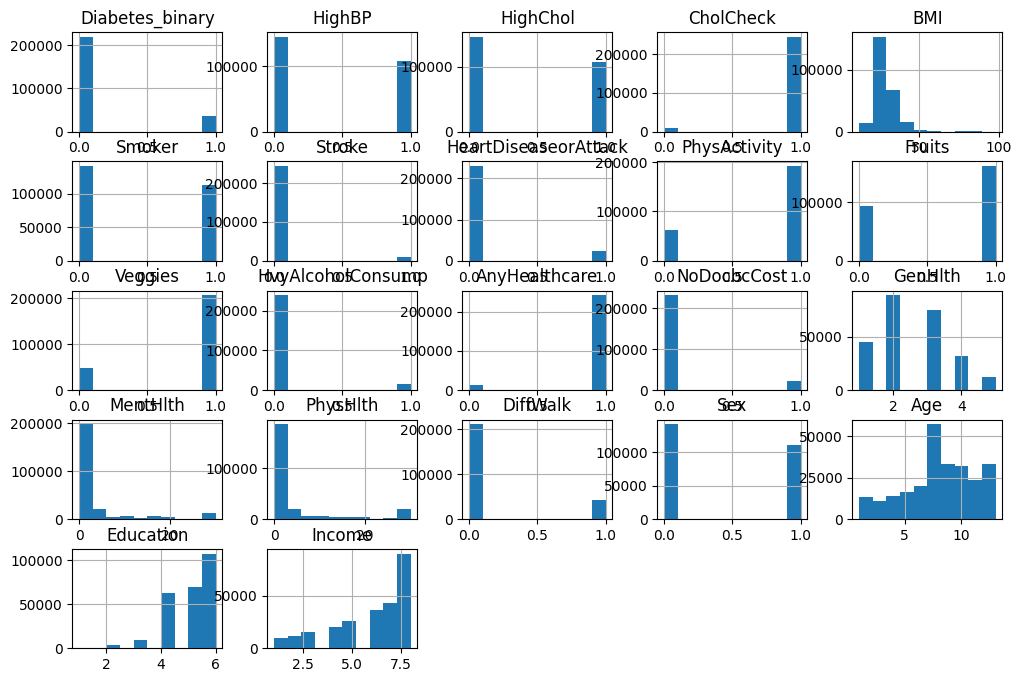

In [22]:
df.hist(figsize=(12, 8))
plt.show()

5. Data Preprocessing

In [23]:
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols)

In [24]:
print(df.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

6. Feature Selection

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
label_encoder = LabelEncoder()

In [28]:
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

In [29]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

In [30]:
print("Features:", X.columns.tolist())

Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


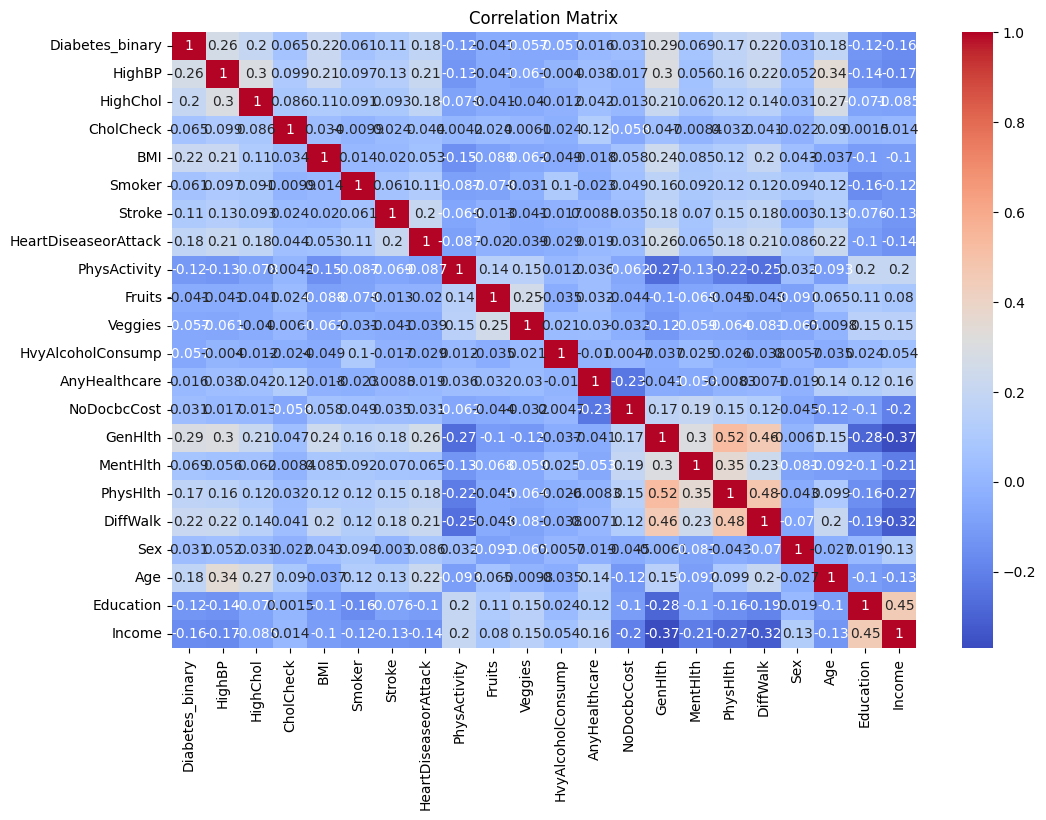

In [31]:
# Correlation Analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [32]:
X_encoded = pd.get_dummies(X)

In [33]:
print(X_encoded.head())

   HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0     1.0       1.0        1.0  40.0     1.0     0.0                   0.0   
1     0.0       0.0        0.0  25.0     1.0     0.0                   0.0   
2     1.0       1.0        1.0  28.0     0.0     0.0                   0.0   
3     1.0       0.0        1.0  27.0     0.0     0.0                   0.0   
4     1.0       1.0        1.0  24.0     0.0     0.0                   0.0   

   PhysActivity  Fruits  Veggies  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0           0.0     0.0      1.0  ...            1.0          0.0      5.0   
1           1.0     0.0      0.0  ...            0.0          1.0      3.0   
2           0.0     1.0      0.0  ...            1.0          1.0      5.0   
3           1.0     1.0      1.0  ...            1.0          0.0      2.0   
4           1.0     1.0      1.0  ...            1.0          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  Income 

In [34]:
print("Shape of Features:", X.shape)
print("Shape of Labels:", y.shape)

Shape of Features: (253680, 21)
Shape of Labels: (253680,)


7. Splitting the Data

In [35]:
#Feature Selection using Information Gain
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(X_encoded, y, random_state=42)
info_gain = pd.Series(info_gain, index=X_encoded.columns)
info_gain = info_gain.sort_values(ascending=False)

In [36]:
print(info_gain)

HighBP                  0.053140
GenHlth                 0.052544
PhysActivity            0.052416
AnyHealthcare           0.050609
CholCheck               0.048799
Fruits                  0.042253
Veggies                 0.042183
HighChol                0.040654
BMI                     0.030828
Sex                     0.025712
Smoker                  0.024667
Age                     0.023585
Education               0.023357
DiffWalk                0.022721
Income                  0.021443
HeartDiseaseorAttack    0.014241
PhysHlth                0.014222
Stroke                  0.004306
MentHlth                0.004185
HvyAlcoholConsump       0.002746
NoDocbcCost             0.000245
dtype: float64


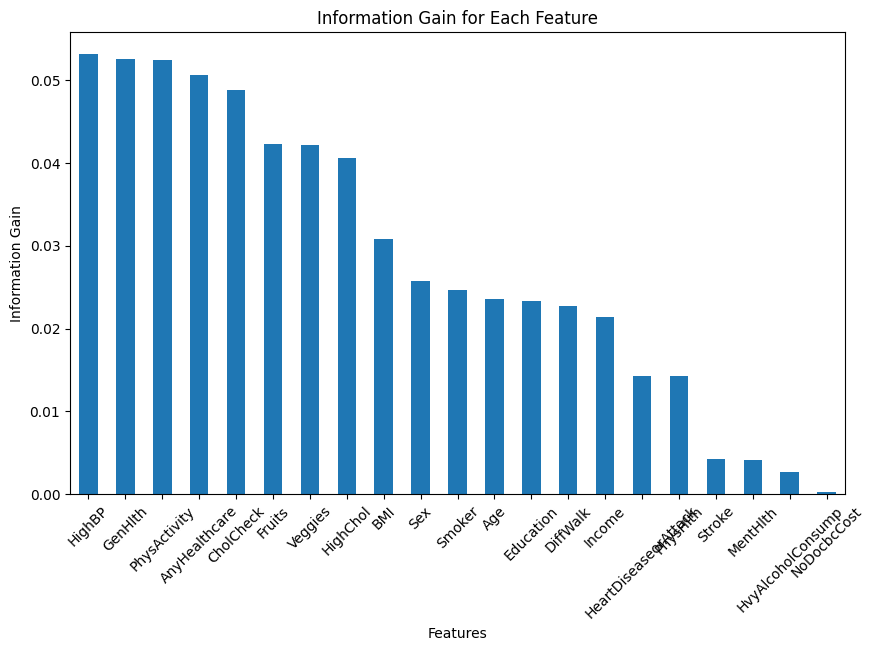

In [37]:
# Plot information gain values
plt.figure(figsize=(10,6))
info_gain.plot(kind='bar')
plt.title('Information Gain for Each Feature')
plt.xlabel('Features')
plt.ylabel('Information Gain')
plt.xticks(rotation=45)
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [39]:
#Splitting the Data
from sklearn.model_selection import train_test_split
# Split data into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
# Split temporary set into validation (20%) and testing (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

In [40]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (177576, 21) (177576,)
Validation set shape: (50736, 21) (50736,)
Testing set shape: (25368, 21) (25368,)


8. Training a Decision Tree Model

In [41]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [43]:
y_pred = dt_classifier.predict(X_val)

In [44]:
# Model Evaluation
accu = accuracy_score(y_val, y_pred)
print("Accuracy:", accu)

Accuracy: 0.7968109429202145


In [45]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88     43664
         1.0       0.29      0.33      0.31      7072

    accuracy                           0.80     50736
   macro avg       0.59      0.60      0.59     50736
weighted avg       0.81      0.80      0.80     50736



In [46]:
print(confusion_matrix(y_val, y_pred))

[[38126  5538]
 [ 4771  2301]]


In [47]:
print(dt_classifier.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [48]:
#Cross-Validation
from sklearn.model_selection import cross_validate , cross_val_score

cv_scores = cross_val_score(dt_classifier, X_encoded, y, cv=5)
print("\nCross-validation Scores:", cv_scores)
print("Mean Cross-validation Score:", np.mean(cv_scores))


Cross-validation Scores: [0.79848628 0.79239593 0.8003193  0.79267187 0.7975205 ]
Mean Cross-validation Score: 0.7962787764112267


In [49]:
y_pred_val = dt_classifier.predict(X_val)

print(y_pred_val)

[0. 0. 0. ... 0. 0. 1.]


10. Hyperparameter Tuning

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Accuracy: 0.8629544499256407


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
800 fits failed out of a total of 2400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
800 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/uti

In [51]:
# Train and evaluate the best model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7968109429202145
Precision: 0.2935323383084577
Recall: 0.32536764705882354
F1 Score: 0.3086312118570183


In [52]:
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(dt_classifier, X, y, cv=5, scoring='accuracy')

# Display cross-validation scores
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.79848628 0.79239593 0.8003193  0.79267187 0.7975205 ]
Mean CV Accuracy: 0.7962787764112267


In [53]:
# Tune hyperparameters
model_tuned = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
model_tuned.fit(X_train, y_train)

# Evaluate the tuned model
y_pred_tuned = model_tuned.predict(X_val)
accuracy_tuned = accuracy_score(y_val, y_pred_tuned)
print("Tuned Model Accuracy:", accuracy_tuned)

Tuned Model Accuracy: 0.8648494165878272


In [54]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))

Random Forest Accuracy: 0.8647902869757175


In [55]:
def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred))
    print("Recall:", recall_score(y_val, y_pred))
    print("F1 Score:", f1_score(y_val, y_pred))

#decision tree
evaluate_model(model_tuned, X_val, y_val)

#random forest
evaluate_model(rf_classifier, X_val, y_val)

Accuracy: 0.8648494165878272
Precision: 0.6111685625646329
Recall: 0.08356900452488687
F1 Score: 0.14703321308620476
Accuracy: 0.8647902869757175
Precision: 0.5552659019812305
Recall: 0.15059389140271492
F1 Score: 0.23692992213570635
